In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
import pandas as pd
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
import time
import torch.nn.functional as F

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set default dtype (replaces deprecated set_default_tensor_type)
torch.set_default_dtype(torch.float32)


Using device: cuda


# ANN

In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(2, 128)
        self.hidden2 = nn.Linear(128, 128)
        self.hidden3 = nn.Linear(128, 128)
        self.hidden4 = nn.Linear(128, 128)
        self.hidden5 = nn.Linear(128, 128)
        self.output = nn.Linear(128, 2)
    def forward(self, x):
        x = torch.tanh(self.hidden1(x))
        x = torch.tanh(self.hidden2(x))
        x = torch.tanh(self.hidden3(x))
        x = torch.tanh(self.hidden4(x))
        x = torch.tanh(self.hidden5(x))
        return self.output(x)  # return [u, v]


# Geometry (Slope stability, multi-layer)

Vertices: (0,0), (0,4), (4,4), (8,2), (13,2), (13,0)

Layer interface (soil boundary between Upper and Lower soil): (0,2) - (8,2)

In [3]:
# Slope geometry vertices (closed polygon)
vertices = np.array([
    [0, 0],
    [0, 4],
    [4, 4],
    [8, 2],
    [13, 2],
    [13, 0],
    [0, 0],  # Closing the polygon
], dtype=np.float32)

path = Path(vertices)

X_MIN, X_MAX = 0.0, 13.0
Y_MIN, Y_MAX = 0.0, 4.0

# Layer interface: horizontal line between Upper soil and Lower soil
# runs from (0, 2) to (8, 2). For x > 8 the whole domain (0..2) is Lower soil.
Y_INTERFACE = 2.0

def in_domain(x, y):
    points = np.column_stack((x.detach().cpu().numpy(), y.detach().cpu().numpy()))
    return torch.tensor(path.contains_points(points), dtype=torch.bool, device=device)


# Material properties (multi-layer soil, no external load)

Upper soil: E = 20 MPa

Lower soil: E = 50 MPa

Unit weight (both layers): gamma = 0.018 MPa (used as self-weight body force, no distributed surface load)

In [4]:
# --- Soil layer properties (smooth transition across the interface) ---
E_UPPER, NU_UPPER = 20.0, 0.3   # Upper soil (y > 2)
E_LOWER, NU_LOWER = 50.0, 0.3   # Lower soil (y <= 2)
NU = 0.3                        # Poisson's ratio (same both layers here)
GAMMA = 0.018                   # Unit weight of soil (MPa), same for both layers

TRANSITION_K = 5.0  # sharpness of the E transition band around the interface
                     # larger k -> narrower/sharper transition (closer to a true jump)
                     # smaller k -> wider/softer transition

def tanh_transition(y, transition_height=Y_INTERFACE, k=TRANSITION_K):
    return 0.5 * (1 + torch.tanh(k * (y - transition_height)))

def calculate_E(y):
    """Smoothly varying Young's modulus: E_LOWER below the interface,
    E_UPPER above it, blended continuously through a tanh transition band
    so that stress derived from it stays continuous everywhere."""
    t = tanh_transition(y)
    return E_LOWER * (1 - t) + E_UPPER * t

def lame_params(y):
    E = calculate_E(y)
    lam = E * NU / ((1 + NU) * (1 - 2 * NU))
    mu = E / (2 * (1 + NU))
    return lam, mu

# Boundary definitions

Boundary segments of the slope geometry:
- Bottom: y = 0, x in [0, 13] -> fixed (ux = 0, uy = 0)
- Left: x = 0, y in [0, 4] -> roller (ux = 0)
- Right: x = 13, y in [0, 2] -> roller (ux = 0)
- Top-left (crest): y = 4, x in [0, 4] -> free surface
- Slope face: line from (4,4) to (8,2) -> free surface
- Top-right (toe bench): y = 2, x in [8, 13] -> free surface

No external load is applied anywhere; only self-weight (unit weight) acts as body force.

In [5]:
tol = 1e-6

# Slope face endpoints
SLOPE_A = (4.0, 4.0)
SLOPE_B = (8.0, 2.0)
_dx = SLOPE_B[0] - SLOPE_A[0]
_dy = SLOPE_B[1] - SLOPE_A[1]
_len = (_dx**2 + _dy**2) ** 0.5
# Outward unit normal to the slope face (pointing away from the soil mass, up-and-right)
SLOPE_NX = -_dy / _len
SLOPE_NY = _dx / _len
if SLOPE_NY < 0:  # ensure it points "outward/upward" away from the soil
    SLOPE_NX, SLOPE_NY = -SLOPE_NX, -SLOPE_NY

def BC_bottom(x, y):
    return ((torch.abs(y - 0.0) < tol) & (x >= X_MIN - tol) & (x <= X_MAX + tol)).squeeze()

def BC_left(x, y):
    return ((torch.abs(x - 0.0) < tol) & (y >= 0.0 - tol) & (y <= 4.0 + tol)).squeeze()

def BC_right(x, y):
    return ((torch.abs(x - 13.0) < tol) & (y >= 0.0 - tol) & (y <= 2.0 + tol)).squeeze()

def BC_top_left(x, y):
    return ((torch.abs(y - 4.0) < tol) & (x >= 0.0 - tol) & (x <= 4.0 + tol)).squeeze()

def BC_top_right(x, y):
    return ((torch.abs(y - 2.0) < tol) & (x >= 8.0 - tol) & (x <= 13.0 + tol)).squeeze()

def BC_slope(x, y):
    # Line from (4,4) to (8,2): y = 4 - 0.5*(x - 4)
    y_line = 4.0 - 0.5 * (x - 4.0)
    return ((torch.abs(y - y_line) < 1e-3) & (x >= 4.0 - tol) & (x <= 8.0 + tol)).squeeze()


# BC Loss

In [6]:
def _stresses(xy_seg, net):
    xy_seg = xy_seg.requires_grad_(True)
    out = net(xy_seg)
    u = out[:, 0:1]
    v = out[:, 1:2]

    u_x = torch.autograd.grad(u.sum(), xy_seg, create_graph=True)[0][:, 0]
    u_y = torch.autograd.grad(u.sum(), xy_seg, create_graph=True)[0][:, 1]
    v_x = torch.autograd.grad(v.sum(), xy_seg, create_graph=True)[0][:, 0]
    v_y = torch.autograd.grad(v.sum(), xy_seg, create_graph=True)[0][:, 1]

    y = xy_seg[:, 1]
    lam, mu = lame_params(y)

    sigma_xx = (lam + 2 * mu) * u_x + lam * v_y
    sigma_yy = lam * u_x + (lam + 2 * mu) * v_y
    sigma_xy = mu * (u_y + v_x)
    return u, v, sigma_xx, sigma_yy, sigma_xy


def BC(xy, net):
    x, y = xy[:, 0].unsqueeze(1), xy[:, 1].unsqueeze(1)

    output = net(xy)
    u = output[:, 0:1]
    v = output[:, 1:2]

    bc_bottom = BC_bottom(x, y)
    bc_left = BC_left(x, y)
    bc_right = BC_right(x, y)
    bc_top_left = BC_top_left(x, y)
    bc_top_right = BC_top_right(x, y)
    bc_slope = BC_slope(x, y)

    loss = torch.tensor(0.0, device=device)

    # --- Bottom: fully fixed ---
    if torch.any(bc_bottom):
        loss = loss + F.mse_loss(u[bc_bottom], torch.zeros_like(u[bc_bottom]))
        loss = loss + F.mse_loss(v[bc_bottom], torch.zeros_like(v[bc_bottom]))

    # --- Left / Right rollers: ux = 0, sigma_xy = 0 ---
    if torch.any(bc_left):
        xy_left = xy[bc_left]
        u_l, v_l, sxx_l, syy_l, sxy_l = _stresses(xy_left, net)
        loss = loss + F.mse_loss(u_l, torch.zeros_like(u_l))
        loss = loss + F.mse_loss(sxy_l, torch.zeros_like(sxy_l))

    if torch.any(bc_right):
        xy_right = xy[bc_right]
        u_r, v_r, sxx_r, syy_r, sxy_r = _stresses(xy_right, net)
        loss = loss + F.mse_loss(u_r, torch.zeros_like(u_r))
        loss = loss + F.mse_loss(sxy_r, torch.zeros_like(sxy_r))

    # --- Top-left crest (horizontal free surface, normal (0,1)) ---
    if torch.any(bc_top_left):
        xy_tl = xy[bc_top_left]
        _, _, sxx_tl, syy_tl, sxy_tl = _stresses(xy_tl, net)
        loss = loss + F.mse_loss(syy_tl, torch.zeros_like(syy_tl))
        loss = loss + F.mse_loss(sxy_tl, torch.zeros_like(sxy_tl))

    # --- Top-right bench (horizontal free surface, normal (0,1)) ---
    if torch.any(bc_top_right):
        xy_tr = xy[bc_top_right]
        _, _, sxx_tr, syy_tr, sxy_tr = _stresses(xy_tr, net)
        loss = loss + F.mse_loss(syy_tr, torch.zeros_like(syy_tr))
        loss = loss + F.mse_loss(sxy_tr, torch.zeros_like(sxy_tr))

    # --- Slope face (inclined free surface): traction-free with slope normal ---
    if torch.any(bc_slope):
        xy_sl = xy[bc_slope]
        _, _, sxx_sl, syy_sl, sxy_sl = _stresses(xy_sl, net)
        nx, ny = SLOPE_NX, SLOPE_NY
        t_x = sxx_sl * nx + sxy_sl * ny
        t_y = sxy_sl * nx + syy_sl * ny
        loss = loss + F.mse_loss(t_x, torch.zeros_like(t_x))
        loss = loss + F.mse_loss(t_y, torch.zeros_like(t_y))

    return loss


# Datapoint sampling (focused on the slope region)

Total in-domain random points generated: 22029
Final points after slope-focused density filtering: 15428


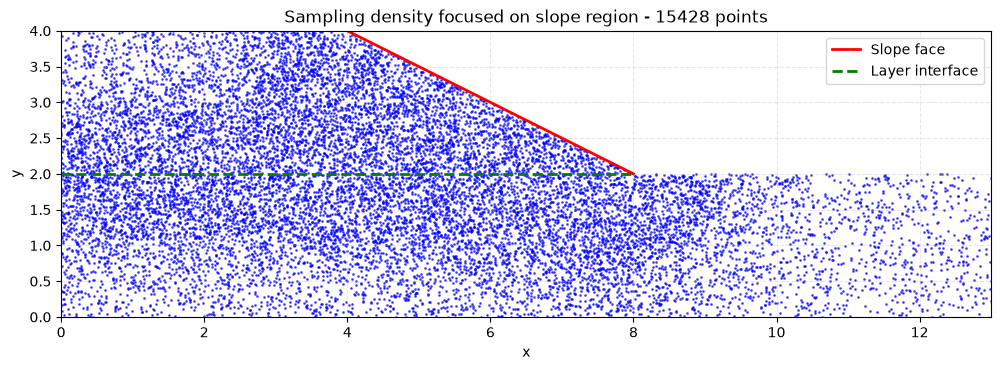

In [7]:
def _point_segment_distance(px, py, ax, ay, bx, by):
    abx, aby = bx - ax, by - ay
    apx, apy = px - ax, py - ay
    ab2 = abx**2 + aby**2
    t = torch.clamp((apx * abx + apy * aby) / ab2, 0.0, 1.0)
    cx, cy = ax + t * abx, ay + t * aby
    return torch.sqrt((px - cx) ** 2 + (py - cy) ** 2)


def generate_point_distribution(n_random=30000, slope_density=8.0, slope_influence=60.0,
                                 interface_density=8.0, interface_influence=30.0, plot=True):
    # Random points over the bounding box, then keep only those inside the slope polygon
    x_random = torch.rand(n_random, device=device) * (X_MAX - X_MIN) + X_MIN
    y_random = torch.rand(n_random, device=device) * (Y_MAX - Y_MIN) + Y_MIN

    inside = in_domain(x_random, y_random)
    x_random = x_random[inside]
    y_random = y_random[inside]

    print(f"Total in-domain random points generated: {len(x_random)}")

    # Distance to the slope face (4,4)-(8,2): sampling emphasis around the critical slope zone
    dist_slope = _point_segment_distance(x_random, y_random, SLOPE_A[0], SLOPE_A[1], SLOPE_B[0], SLOPE_B[1])

    # Distance to the layer interface (0,2)-(8,2), only meaningful where the interface exists (x <= 8)
    dist_interface = torch.abs(y_random - Y_INTERFACE)
    dist_interface = torch.where(x_random <= 8.0, dist_interface, torch.full_like(dist_interface, 1e3))

    base_prob = 0.15
    slope_prob = slope_influence / (1 + (dist_slope * slope_density) ** 2)
    interface_prob = interface_influence / (1 + (dist_interface * interface_density) ** 2)

    keep_prob = torch.clamp(base_prob + slope_prob + interface_prob, 0.0, 1.0)
    keep_mask = torch.rand(len(x_random), device=device) < keep_prob

    x_final = x_random[keep_mask]
    y_final = y_random[keep_mask]

    print(f"Final points after slope-focused density filtering: {len(x_final)}")

    if plot:
        plt.figure(figsize=(12, 6))
        plt.scatter(x_final.detach().cpu().numpy(), y_final.detach().cpu().numpy(), s=1, color='blue', alpha=0.6)
        plt.plot([SLOPE_A[0], SLOPE_B[0]], [SLOPE_A[1], SLOPE_B[1]], 'r-', linewidth=2, label='Slope face')
        plt.plot([0, 8], [Y_INTERFACE, Y_INTERFACE], 'g--', linewidth=2, label='Layer interface')
        plt.xlim(X_MIN, X_MAX)
        plt.ylim(Y_MIN, Y_MAX)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'Sampling density focused on slope region - {len(x_final)} points')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.gca().set_aspect('equal')
        plt.legend()
        plt.show()

    return x_final, y_final


x_points, y_points = generate_point_distribution()


# PDE (self-weight only, no external load)

In [8]:
def PDE(x, y, net):
    x_reshaped = x.unsqueeze(1) if x.dim() == 1 else x
    y_reshaped = y.unsqueeze(1) if y.dim() == 1 else y

    xy = torch.cat([x_reshaped, y_reshaped], dim=1)
    xy.requires_grad = True

    output = net(xy)
    u = output[:, 0:1]
    v = output[:, 1:2]

    u_x = torch.autograd.grad(u.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1)
    u_y = torch.autograd.grad(u.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1)
    v_x = torch.autograd.grad(v.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1)
    v_y = torch.autograd.grad(v.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1)

    lam, mu = lame_params(xy[:, 1:2])  # spatially varying (layered) material

    sigma_xx = (lam + 2 * mu) * u_x + lam * v_y
    sigma_yy = lam * u_x + (lam + 2 * mu) * v_y
    sigma_xy = mu * (u_y + v_x)

    # Body force: self-weight only, no external distributed load
    f_x = torch.zeros_like(x_reshaped)
    f_y = -GAMMA * torch.ones_like(y_reshaped)

    R_x = torch.autograd.grad(sigma_xx.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1) + \
          torch.autograd.grad(sigma_xy.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1) + f_x
    R_y = torch.autograd.grad(sigma_xy.sum(), xy, create_graph=True)[0][:, 0].unsqueeze(1) + \
          torch.autograd.grad(sigma_yy.sum(), xy, create_graph=True)[0][:, 1].unsqueeze(1) + f_y

    loss_x = F.mse_loss(R_x, torch.zeros_like(R_x))
    loss_y = F.mse_loss(R_y, torch.zeros_like(R_y))

    return loss_x, loss_y


# Training

In [9]:
from tqdm.auto import tqdm

def train(net, optimizer, n_epochs, batch_size=32):
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)

    best_loss = float('inf')

    loss_history = []
    pde_x_history = []
    pde_y_history = []
    bc_history = []
    epoch_history = []

    print("Generating training points...")
    x_inner, y_inner = generate_point_distribution(plot=False)
    print(f"Generated {len(x_inner)} interior points")

    print("Generating boundary points...")
    num_boundary_points = 1000

    x_bottom = torch.linspace(0, 13, num_boundary_points, device=device)
    y_bottom = torch.zeros(num_boundary_points, device=device)

    x_left = torch.zeros(num_boundary_points, device=device)
    y_left = torch.linspace(0, 4, num_boundary_points, device=device)

    x_right = torch.ones(num_boundary_points, device=device) * 13
    y_right = torch.linspace(0, 2, num_boundary_points, device=device)

    x_top_left = torch.linspace(0, 4, num_boundary_points, device=device)
    y_top_left = torch.ones(num_boundary_points, device=device) * 4

    x_top_right = torch.linspace(8, 13, num_boundary_points, device=device)
    y_top_right = torch.ones(num_boundary_points, device=device) * 2

    x_slope = torch.linspace(4, 8, num_boundary_points, device=device)
    y_slope = 4.0 - 0.5 * (x_slope - 4.0)

    x_b = torch.cat([x_bottom, x_left, x_right, x_top_left, x_top_right, x_slope])
    y_b = torch.cat([y_bottom, y_left, y_right, y_top_left, y_top_right, y_slope])

    xy_b = torch.stack([x_b, y_b], dim=1)
    print(f"Generated {len(xy_b)} boundary points")

    n_inner = len(x_inner)
    n_boundary = len(xy_b)

    print(f"Starting training for {n_epochs} epochs with batch_size={batch_size}...")

    pbar = tqdm(range(n_epochs), desc="Training", unit="epoch")

    for epoch in pbar:
        inner_idx = torch.randint(0, n_inner, (batch_size,), device=device)
        boundary_idx = torch.randint(0, n_boundary, (batch_size,), device=device)

        x_batch = x_inner[inner_idx]
        y_batch = y_inner[inner_idx]
        xy_b_batch = xy_b[boundary_idx]

        optimizer.zero_grad()

        loss_pde_x, loss_pde_y = PDE(x_batch, y_batch, net)
        loss_bc = BC(xy_b_batch, net)

        loss = loss_pde_x + loss_pde_y + loss_bc

        loss.backward()

        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=0.5)

        optimizer.step()
        scheduler.step()

        loss_history.append(loss.item())
        pde_x_history.append(loss_pde_x.item())
        pde_y_history.append(loss_pde_y.item())
        bc_history.append(loss_bc.item())
        epoch_history.append(epoch)

        if loss < best_loss:
            best_loss = loss

            torch.save({
                'net_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': loss,
                'epoch': epoch,
            }, 'best_model.pth')

        pbar.set_postfix({
            'Loss': f'{loss.item():.6f}',
            'PDE_x': f'{loss_pde_x.item():.6f}',
            'PDE_y': f'{loss_pde_y.item():.6f}',
            'BC': f'{loss_bc.item():.6f}',
            'LR': f'{scheduler.get_last_lr()[0]:.2e}'
        })

        if (epoch + 1) % 10000 == 0:
            tqdm.write(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.10f}, '
                       f'PDE_x: {loss_pde_x.item():.10f}, PDE_y: {loss_pde_y.item():.10f}, '
                       f'BC: {loss_bc.item():.10f}, LR: {scheduler.get_last_lr()[0]:.10f}')

    pbar.close()

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epoch_history, loss_history, 'b-', label='Total Loss')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss History')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(epoch_history, pde_x_history, 'r-', label='PDE_x Loss')
    plt.plot(epoch_history, pde_y_history, 'g-', label='PDE_y Loss')
    plt.plot(epoch_history, bc_history, 'b-', label='BC Loss')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Component Losses (log scale)')
    plt.title('Component Losses History')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('loss_history.png')
    plt.close()

    metrics = {
        'loss_history': loss_history,
        'pde_x_history': pde_x_history,
        'pde_y_history': pde_y_history,
        'bc_history': bc_history,
        'epoch_history': epoch_history
    }

    print("Training completed.")
    return net, metrics

# Plot result

In [10]:
def plot_results(net, output_filename='Slope_data.csv'):
    nx, ny = 100, 100
    X = torch.linspace(X_MIN, X_MAX, nx, device=device)
    Y = torch.linspace(Y_MIN, Y_MAX, ny, device=device)

    xx, yy = torch.meshgrid(X, Y, indexing='ij')

    X = xx.flatten()
    Y = yy.flatten()

    mask = in_domain(X, Y)
    mask_np = mask.cpu().numpy()

    XY = torch.stack([X, Y], dim=1)
    XY.requires_grad_(True)

    with torch.enable_grad():
        output = net(XY)
        U = output[:, 0:1]
        V = output[:, 1:2]

        U_x = torch.autograd.grad(U.sum(), XY, create_graph=True)[0][:, 0]
        U_y = torch.autograd.grad(U.sum(), XY, create_graph=True)[0][:, 1]
        V_x = torch.autograd.grad(V.sum(), XY, create_graph=True)[0][:, 0]
        V_y = torch.autograd.grad(V.sum(), XY, create_graph=True)[0][:, 1]

        lam, mu = lame_params(Y.unsqueeze(1))

        sigma_xx = (lam + 2 * mu) * U_x.unsqueeze(1) + lam * V_y.unsqueeze(1)
        sigma_yy = lam * U_x.unsqueeze(1) + (lam + 2 * mu) * V_y.unsqueeze(1)
        sigma_xy = mu * (U_y.unsqueeze(1) + V_x.unsqueeze(1))

    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()
    U_full = U.detach().cpu().numpy().squeeze()
    V_full = V.detach().cpu().numpy().squeeze()
    sigma_xx_full = sigma_xx.detach().cpu().numpy().squeeze() * 1000
    sigma_yy_full = sigma_yy.detach().cpu().numpy().squeeze() * 1000
    sigma_xy_full = sigma_xy.detach().cpu().numpy().squeeze() * 1000

    magnitude = np.sqrt(U_full**2 + V_full**2)

    df_out = pd.DataFrame({
        'X': X_np[mask_np],
        'Y': Y_np[mask_np],
        'ux': U_full[mask_np],
        'uy': V_full[mask_np],
        'sigma_xx': sigma_xx_full[mask_np],
        'sigma_yy': sigma_yy_full[mask_np],
        'sigma_xy': sigma_xy_full[mask_np],
        'magnitude': magnitude[mask_np]
    })

    df_out.to_csv(output_filename, index=False)
    print(f"Results saved to {output_filename}")

    mask_cpu = mask.cpu().numpy()
    U_masked = np.ma.masked_array(U_full, mask=~mask_cpu)
    V_masked = np.ma.masked_array(V_full, mask=~mask_cpu)
    sigma_xx_masked = np.ma.masked_array(sigma_xx_full, mask=~mask_cpu)
    sigma_yy_masked = np.ma.masked_array(sigma_yy_full, mask=~mask_cpu)
    sigma_xy_masked = np.ma.masked_array(sigma_xy_full, mask=~mask_cpu)
    magnitude_masked = np.ma.masked_array(magnitude, mask=~mask_cpu)

    def _overlay(ax):
        ax.plot([SLOPE_A[0], SLOPE_B[0]], [SLOPE_A[1], SLOPE_B[1]], 'k-', linewidth=1.5)
        ax.plot([0, 8], [Y_INTERFACE, Y_INTERFACE], 'w--', linewidth=1.2)

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.pcolormesh(X_np.reshape(nx, ny), Y_np.reshape(nx, ny), U_masked.reshape(nx, ny), shading='auto', cmap='jet')
    plt.colorbar(label='Displacement ux (m)')
    plt.title('Displacement in x-direction')
    _overlay(plt.gca())
    plt.xlabel('X'); plt.ylabel('Y'); plt.gca().set_aspect('equal')

    plt.subplot(2, 3, 2)
    plt.pcolormesh(X_np.reshape(nx, ny), Y_np.reshape(nx, ny), V_masked.reshape(nx, ny), shading='auto', cmap='jet')
    plt.colorbar(label='Displacement uy (m)')
    plt.title('Displacement in y-direction')
    _overlay(plt.gca())
    plt.xlabel('X'); plt.ylabel('Y'); plt.gca().set_aspect('equal')

    plt.subplot(2, 3, 3)
    plt.pcolormesh(X_np.reshape(nx, ny), Y_np.reshape(nx, ny), magnitude_masked.reshape(nx, ny), shading='auto', cmap='jet')
    plt.colorbar(label='Displacement magnitude (m)')
    plt.title('Displacement magnitude')
    _overlay(plt.gca())
    plt.xlabel('X'); plt.ylabel('Y'); plt.gca().set_aspect('equal')

    plt.subplot(2, 3, 4)
    plt.pcolormesh(X_np.reshape(nx, ny), Y_np.reshape(nx, ny), sigma_xx_masked.reshape(nx, ny), shading='auto', cmap='jet')
    plt.colorbar(label='Stress sigma_xx (kPa)')
    plt.title('Normal stress sigma_xx')
    _overlay(plt.gca())
    plt.xlabel('X'); plt.ylabel('Y'); plt.gca().set_aspect('equal')

    plt.subplot(2, 3, 5)
    plt.pcolormesh(X_np.reshape(nx, ny), Y_np.reshape(nx, ny), sigma_yy_masked.reshape(nx, ny), shading='auto', cmap='jet')
    plt.colorbar(label='Stress sigma_yy (kPa)')
    plt.title('Normal stress sigma_yy')
    _overlay(plt.gca())
    plt.xlabel('X'); plt.ylabel('Y'); plt.gca().set_aspect('equal')

    plt.subplot(2, 3, 6)
    plt.pcolormesh(X_np.reshape(nx, ny), Y_np.reshape(nx, ny), sigma_xy_masked.reshape(nx, ny), shading='auto', cmap='jet')
    plt.colorbar(label='Stress sigma_xy (kPa)')
    plt.title('Shear stress sigma_xy')
    _overlay(plt.gca())
    plt.xlabel('X'); plt.ylabel('Y'); plt.gca().set_aspect('equal')

    plt.tight_layout()
    plt.savefig('results_plots.png', dpi=300)
    plt.close()
    print("Result plots saved to results_plots.png")


# Main execution

In [11]:
if __name__ == "__main__":
    print(f"Using device: {device}")

    # Initialize network and optimizer
    net = Net().to(device)
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    # Train the network
    trained_net, metrics = train(net=net, optimizer=optimizer, n_epochs=60000, batch_size=1024)

    # Plot results
    try:
        plot_results(trained_net)
    except Exception as e:
        print(f"Error in plot_results: {str(e)}")


Using device: cuda
Generating training points...
Total in-domain random points generated: 21818
Final points after slope-focused density filtering: 15252
Generated 15252 interior points
Generating boundary points...
Generated 6000 boundary points
Starting training for 60000 epochs with batch_size=1024...


Training:   0%|          | 0/60000 [00:00<?, ?epoch/s]

Epoch 10000/60000, Loss: 0.0000555176, PDE_x: 0.0000003707, PDE_y: 0.0000500585, BC: 0.0000050884, LR: 0.0009330797
Epoch 20000/60000, Loss: 0.0000035266, PDE_x: 0.0000001993, PDE_y: 0.0000025875, BC: 0.0000007398, LR: 0.0007502500
Epoch 30000/60000, Loss: 0.0000006394, PDE_x: 0.0000000290, PDE_y: 0.0000001093, BC: 0.0000005011, LR: 0.0005005000
Epoch 40000/60000, Loss: 0.0000001803, PDE_x: 0.0000000222, PDE_y: 0.0000000473, BC: 0.0000001107, LR: 0.0002507500
Epoch 50000/60000, Loss: 0.0000001508, PDE_x: 0.0000000188, PDE_y: 0.0000000204, BC: 0.0000001116, LR: 0.0000679203
Epoch 60000/60000, Loss: 0.0000000919, PDE_x: 0.0000000115, PDE_y: 0.0000000123, BC: 0.0000000682, LR: 0.0000010000
Training completed.
Results saved to Slope_data.csv
Result plots saved to results_plots.png
